# Vietnamese Emotion Classification - CNN + BiGRU

**Google Colab Ready** - optimized for GPU acceleration.

This notebook implements a **CNN + BiGRU** hybrid architecture for Vietnamese emotion classification:

- **CNN layers** extract local n-gram features from the embedding sequence
- **BiGRU** captures long-range bidirectional dependencies
- **Attention pooling** summarizes the sequence into a fixed-length vector

### How to Use
1. Upload training data to Google Drive at: `MyDrive/thesis/data/`
   - Required: `processed/train_10000_final.csv`, `processed/val_processed.csv`, `processed/test_processed.csv`
2. Enable GPU: **Runtime → Change runtime type → GPU**
3. Run cells in order

---

## Techniques Implemented

1. **Multi-kernel CNN** - parallel Conv1D with kernel sizes 2, 3, 4, 5 for capturing different n-gram patterns
2. **Bidirectional GRU** - captures forward and backward contextual information
3. **Early Stopping & LR Scheduling** - monitors validation loss
4. **Mixed Precision (FP16)** - enabled automatically on GPU
5. **W&B Logging** - tracks training metrics

## 0. Google Colab Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully")
print("Data should be in: /content/drive/MyDrive/thesis/data")

try:
    import torch_xla
    import torch_xla.core.xla_model as xm
    TPU_AVAILABLE = True
    print("TPU detected and configured")
except ImportError:
    TPU_AVAILABLE = False
    print("TPU not available, will use GPU/CPU")

Mounted at /content/drive
Google Drive mounted successfully
Data should be in: /content/drive/MyDrive/thesis/data
TPU not available, will use GPU/CPU


In [2]:
%pip install -q pandas numpy scikit-learn matplotlib seaborn tensorflow keras wandb underthesea openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 49.1 MB/s eta 0:00:00


In [3]:
import os
import json
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    MaxPooling1D,
    GRU,
    Bidirectional,
    Dense,
    Dropout,
    Concatenate,
    BatchNormalization,
    GlobalMaxPooling1D,
    SpatialDropout1D,
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print(f"GPU(s) detected: {[g.name for g in gpus]}")
    print(f"Mixed-precision policy: {tf.keras.mixed_precision.global_policy().name}")
else:
    print("No GPU detected - running on CPU.")

print(f"TensorFlow version: {tf.__version__}")

GPU(s) detected: ['/physical_device:GPU:0']
Mixed-precision policy: mixed_float16
TensorFlow version: 2.19.0


## 1. Configuration

In [9]:
# Single run configuration (TEST MODE)
NUM_RUNS = 1
SEEDS = [42]

# Data paths
DATA_DIR = '/content/drive/MyDrive/thesis/data/'
MODEL_SAVE_PATH = '/content/drive/MyDrive/thesis/emotion_classifier_cnn_bigru'

# Tokenizer / embedding settings
MAX_WORDS = 50000
MAX_SEQ_LEN = 256
EMBED_DIM = 128

# CNN settings
CNN_FILTERS = 128
CNN_KERNEL_SIZES = [2, 3, 4, 5]

# BiGRU settings
GRU_UNITS = 128

# Training settings
TRAIN_BATCH_SIZE = 128
VAL_BATCH_SIZE = 512
LEARNING_RATE = 1e-3
NUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5
LR_REDUCE_PATIENCE = 2
LR_REDUCE_FACTOR = 0.5
LR_MIN = 1e-6

# Cross-validation
K_FOLDS = 5

# Text preprocessing
USE_UNDERTHESEA_TOKENIZER = True

print("Configuration loaded (TEST MODE - Single Run)")
print(f"  Data dir: {DATA_DIR}")
print(f"  Model save path: {MODEL_SAVE_PATH}")
print(f"  Max vocabulary: {MAX_WORDS}")
print(f"  Max sequence length: {MAX_SEQ_LEN}")
print(f"  Embedding dim: {EMBED_DIM}")
print(f"  CNN filters: {CNN_FILTERS}, kernels: {CNN_KERNEL_SIZES}")
print(f"  BiGRU units: {GRU_UNITS}")
print(f"  Batch size (train): {TRAIN_BATCH_SIZE}")
print(f"  Batch size (eval): {VAL_BATCH_SIZE}")
print(f"  Learning Rate: {LEARNING_RATE:.1e}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Underthesea tokenizer: {USE_UNDERTHESEA_TOKENIZER}")
print(f"  Number of runs: {NUM_RUNS} (seeds: {SEEDS})")

Configuration loaded (TEST MODE - Single Run)
  Data dir: /content/drive/MyDrive/thesis/data/
  Model save path: /content/drive/MyDrive/thesis/emotion_classifier_cnn_bigru
  Max vocabulary: 50000
  Max sequence length: 256
  Embedding dim: 128
  CNN filters: 128, kernels: [2, 3, 4, 5]
  BiGRU units: 128
  Batch size (train): 128
  Batch size (eval): 512
  Learning Rate: 1.0e-03
  Epochs: 30
  Underthesea tokenizer: True
  Number of runs: 1 (seeds: [42])


## 2. Weights & Biases Setup

In [6]:
import wandb
from google.colab import userdata

try:
    wandb_key = userdata.get('WANDB_API_KEY')
    wandb.login(key=wandb_key)
    print("W&B login successful")
except Exception as e:
    print(f"W&B login failed: {e}")
    print("Training will continue without W&B logging")

# Removed wandb.init() from here as it's not needed for the fix of the previous error.
# The wandb.init() was already set up globally in the original notebook.


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nguyengiahuy13104 (https-hcmiu-edu-vn-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B login successful


## 3. Load and Prepare Data

In [7]:
if USE_UNDERTHESEA_TOKENIZER:
    from underthesea import word_tokenize

    def tokenize_vietnamese(text):
        try:
            return word_tokenize(str(text), format='text')
        except Exception:
            return str(text)

    print("Underthesea tokenizer loaded")
else:
    print("Using raw text (no Underthesea tokenization)")

Underthesea tokenizer loaded


In [16]:
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
print(f"Model save directory ready: {MODEL_SAVE_PATH}")

train_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/train_1500_para_final.csv'))
val_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/val_processed.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/ttest_gen_final.csv'))

print(f"\nDatasets loaded from Google Drive")
print(f"  Train: {train_df.shape[0]} samples")
print(f"  Val: {val_df.shape[0]} samples")
print(f"  Test: {test_df.shape[0]} samples")

train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Training data shuffled (random_state=42)")

# The kernel state for train_df after this block confirms this.
train_df = train_df.drop(['Emotion', 'Sentence'], axis=1)
train_df.columns = ['label', 'text']

# Fix for val_df and test_df:
# Original columns are 'Emotion', 'Sentence', 'emotion_vn'.
# We want 'text' from 'Sentence' and 'label' from 'emotion_vn', dropping 'Emotion'.
val_df = val_df.rename(columns={'Sentence': 'text', 'emotion_vn': 'label'}).drop('Emotion', axis=1)
test_df = test_df.rename(columns={'Sentence': 'text', 'emotion_vn': 'label'}).drop('Emotion', axis=1)

for current_df in [train_df, val_df, test_df]:
    current_df.dropna(subset=['text', 'label'], inplace=True)
    current_df['text'] = current_df['text'].astype(str).str.strip()
    current_df['label'] = current_df['label'].astype(str).str.strip()

    if USE_UNDERTHESEA_TOKENIZER:
        current_df['text'] = current_df['text'].apply(tokenize_vietnamese)
        print(f"Applied underthesea tokenization to {current_df.shape[0]} samples")

print(f"\n{'='*80}")
print("SAMPLE TEXT")
print(f"{'='*80}")
for i in range(3):
    print(f"Sample {i+1}: {train_df['text'].iloc[i][:150]}...")
print(f"{'='*80}")
print("\nData loaded and cleaned successfully")

Model save directory ready: /content/drive/MyDrive/thesis/emotion_classifier_cnn_bigru

Datasets loaded from Google Drive
  Train: 10541 samples
  Val: 686 samples
  Test: 963 samples
Training data shuffled (random_state=42)
Applied underthesea tokenization to 10541 samples
Applied underthesea tokenization to 686 samples
Applied underthesea tokenization to 963 samples

SAMPLE TEXT
Sample 1: ôi trời_ơi , không ngờ lại là em đó hả buồn_bã thật_sự bất_ngờ luôn , lâu lắm rồi mình không gặp nhau ấy ....
Sample 2: có những ngày làm tới đâu là sai tới đó cười lớn muốn tát vào mặt hết_sức...
Sample 3: bữa_nay đi ngang vẫn nghe kể chuyện xả thải thẳng xuống sông , không biết khi nào sông mình mới sạch nổi đây . haizz ....

Data loaded and cleaned successfully


## 4. Analyze Class Distribution

Emotion distribution (Training set):
label
vui vẻ        1556
buồn          1500
ngạc nhiên    1499
khác          1499
khó chịu      1498
giận dữ       1496
sợ hãi        1493
Name: count, dtype: int64

Imbalance ratio: 1.0:1


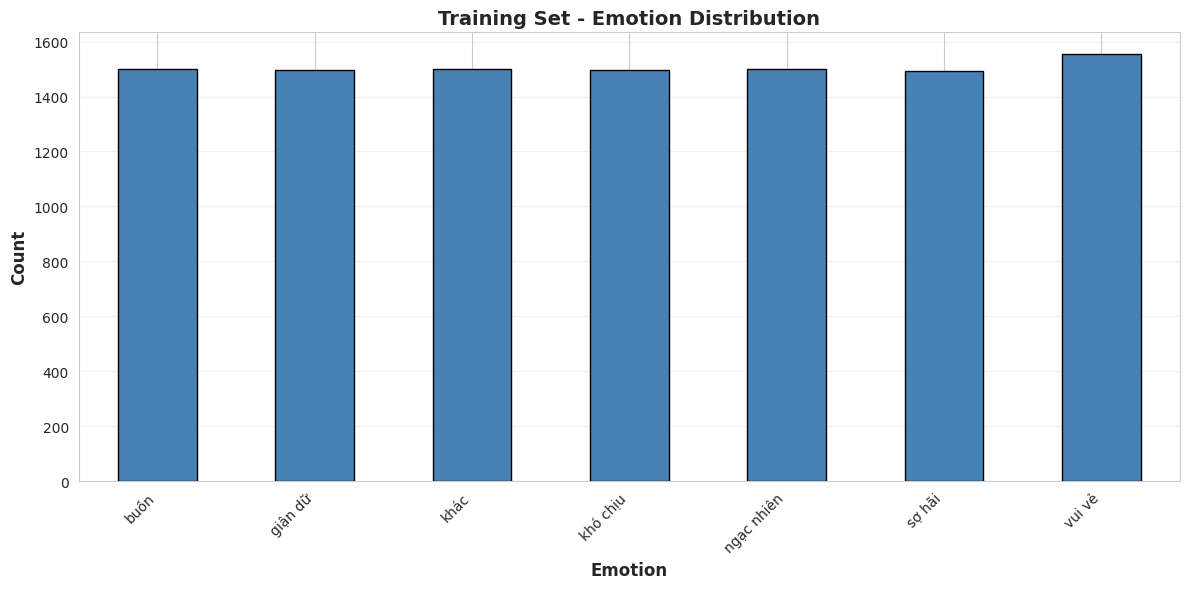


Label mappings created (7 classes)
Classes: [np.str_('buồn'), np.str_('giận dữ'), np.str_('khác'), np.str_('khó chịu'), np.str_('ngạc nhiên'), np.str_('sợ hãi'), np.str_('vui vẻ')]


In [17]:
label_counts = train_df['label'].value_counts()
print("Emotion distribution (Training set):")
print(label_counts)
print(f"\nImbalance ratio: {label_counts.max() / label_counts.min():.1f}:1")

plt.figure(figsize=(12, 6))
label_counts.sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Emotion', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Training Set - Emotion Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Label encoding
le = LabelEncoder()
le.fit(sorted(train_df['label'].unique()))

y_train = le.transform(train_df['label'])
y_val = le.transform(val_df['label'])
y_test = le.transform(test_df['label'])

num_classes = len(le.classes_)
label2id = {label: int(idx) for idx, label in enumerate(le.classes_)}
id2label = {int(idx): label for label, idx in label2id.items()}

print(f"\nLabel mappings created ({num_classes} classes)")
print(f"Classes: {list(le.classes_)}")

## 5. Tokenize & Pad Sequences

In [18]:
# Combine train + val for K-Fold cross-validation
cv_df = pd.concat([train_df, val_df], ignore_index=True)
y_cv = np.concatenate([y_train, y_val])
print(f"Combined train+val for CV: {len(cv_df)} samples")

text_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
text_tokenizer.fit_on_texts(cv_df['text'])

X_cv_seq = text_tokenizer.texts_to_sequences(cv_df['text'])
X_test_seq = text_tokenizer.texts_to_sequences(test_df['text'])

X_cv_pad = pad_sequences(X_cv_seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

y_cv_cat = to_categorical(y_cv, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

vocab_size = min(MAX_WORDS, len(text_tokenizer.word_index) + 1)

print(f"Tokenizer word_index size: {len(text_tokenizer.word_index)}")
print(f"Effective vocab_size: {vocab_size}")
print(f"Max sequence length: {MAX_SEQ_LEN}")
print(f"X_cv (train+val) shape: {X_cv_pad.shape}")
print(f"y_cv (train+val) shape: {y_cv_cat.shape}")
print(f"X_test shape: {X_test_pad.shape}")
print(f"K-Fold splits: {K_FOLDS}")

Tokenizer word_index size: 4420
Effective vocab_size: 4421
Max sequence length: 256
X_train shape: (10541, 256)
X_val shape: (686, 256)
X_test shape: (963, 256)
y_train shape: (10541, 7)


### Sequence Length Distribution

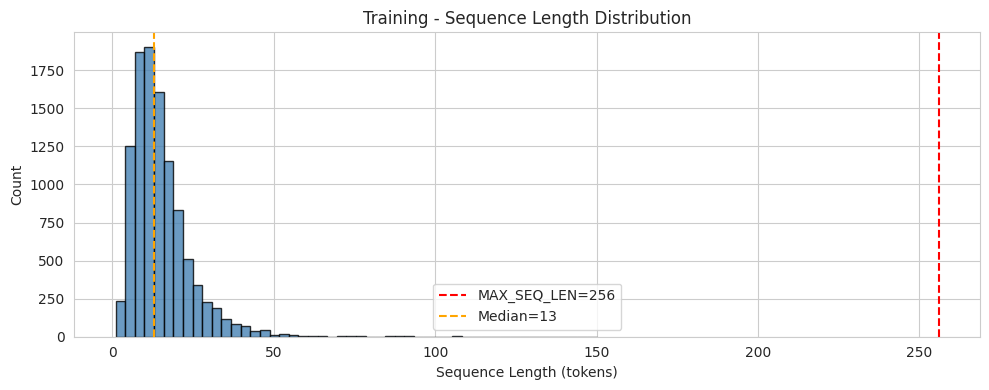

100.0% of training sequences fit within MAX_SEQ_LEN=256


In [19]:
seq_lengths = [len(s) for s in X_cv_seq]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(seq_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(MAX_SEQ_LEN, color='red', linestyle='--', label=f'MAX_SEQ_LEN={MAX_SEQ_LEN}')
ax.axvline(np.median(seq_lengths), color='orange', linestyle='--', label=f'Median={np.median(seq_lengths):.0f}')
ax.set_title('Training - Sequence Length Distribution')
ax.set_xlabel('Sequence Length (tokens)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

pct_within = np.mean([l <= MAX_SEQ_LEN for l in seq_lengths]) * 100
print(f"{pct_within:.1f}% of training sequences fit within MAX_SEQ_LEN={MAX_SEQ_LEN}")

## 6. Build CNN + BiGRU Model

In [20]:
def build_cnn_bigru(vocab_size, embed_dim, max_len, num_classes,
                    cnn_filters=128, kernel_sizes=[2, 3, 4, 5],
                    gru_units=128):
    """
    Hybrid CNN + BiGRU architecture:
      Embedding -> SpatialDropout
        -> Multi-kernel CNN branches (concatenated)
        -> BiGRU
        -> GlobalMaxPooling
        -> Dense -> Softmax
    """
    inp = Input(shape=(max_len,))

    x = Embedding(vocab_size, embed_dim, input_length=max_len)(inp)
    x = SpatialDropout1D(0.2)(x)

    # Multi-kernel CNN: each branch captures different n-gram patterns
    conv_outputs = []
    for ks in kernel_sizes:
        conv = Conv1D(cnn_filters, kernel_size=ks, activation='relu', padding='same')(x)
        conv = BatchNormalization()(conv)
        conv_outputs.append(conv)

    if len(conv_outputs) > 1:
        x = Concatenate(axis=-1)(conv_outputs)
    else:
        x = conv_outputs[0]

    x = Dropout(0.3)(x)

    # BiGRU to capture sequential dependencies from CNN features
    x = Bidirectional(GRU(gru_units, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    x = GlobalMaxPooling1D()(x)

    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    out = Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(inputs=inp, outputs=out)
    return model


model = build_cnn_bigru(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    max_len=MAX_SEQ_LEN,
    num_classes=num_classes,
    cnn_filters=CNN_FILTERS,
    kernel_sizes=CNN_KERNEL_SIZES,
    gru_units=GRU_UNITS,
)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 128)  │    565,888 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 256, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 256, 128)  │     32,896 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 256, 128)  │     49,280 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 256, 128)  │     65,664 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 256, 128)  │     82,048 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 128)  │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 512)  │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 512)  │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 256, 256)  │    493,056 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256, 256)  │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ dropout_1[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,332,999 (5.08 MB)

 Trainable params: 1,331,719 (5.08 MB)

 Non-trainable params: 1,280 (5.00 KB)


Total parameters: 1,332,999


## 7. Train Model (K-Fold Cross-Validation)

In [22]:
all_fold_results = []
best_fold_f1_weighted = 0
best_fold_idx = None
best_model_ref = None
best_history = None

seed = SEEDS[0]
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=seed)

print(f"\n{'='*80}")
print(f"{K_FOLDS}-FOLD CROSS-VALIDATION TRAINING")
print(f"Seed: {seed}")
print(f"{'='*80}\n")

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_cv_pad, y_cv)):
    print(f"\n{'='*80}")
    print(f"FOLD {fold_idx + 1}/{K_FOLDS}")
    print(f"  Train samples: {len(train_idx)}, Val samples: {len(val_idx)}")
    print(f"{'='*80}\n")

    X_fold_train, X_fold_val = X_cv_pad[train_idx], X_cv_pad[val_idx]
    y_fold_train, y_fold_val = y_cv_cat[train_idx], y_cv_cat[val_idx]

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    model = build_cnn_bigru(
        vocab_size=vocab_size,
        embed_dim=EMBED_DIM,
        max_len=MAX_SEQ_LEN,
        num_classes=num_classes,
        cnn_filters=CNN_FILTERS,
        kernel_sizes=CNN_KERNEL_SIZES,
        gru_units=GRU_UNITS,
    )

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    checkpoint_path = f'./cnn_bigru_best_fold_{fold_idx + 1}.keras'
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=LR_REDUCE_FACTOR,
            patience=LR_REDUCE_PATIENCE,
            min_lr=LR_MIN,
            verbose=1,
        ),
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=1,
        ),
        wandb.keras.WandbMetricsLogger(log_freq='epoch'), # Replaced deprecated WandbCallback
    ]

    history = model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=NUM_EPOCHS,
        batch_size=TRAIN_BATCH_SIZE,
        validation_batch_size=VAL_BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    y_val_prob = model.predict(X_fold_val, batch_size=VAL_BATCH_SIZE, verbose=0)
    y_val_pred = np.argmax(y_val_prob, axis=1)
    y_val_true = np.argmax(y_fold_val, axis=1)

    val_accuracy = accuracy_score(y_val_true, y_val_pred)
    val_f1_macro = f1_score(y_val_true, y_val_pred, average='macro')
    val_f1_weighted = f1_score(y_val_true, y_val_pred, average='weighted')

    y_test_prob = model.predict(X_test_pad, batch_size=VAL_BATCH_SIZE, verbose=0)
    y_test_pred = np.argmax(y_test_prob, axis=1)

    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
    test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')

    fold_results = {
        'fold': fold_idx + 1,
        'val_accuracy': val_accuracy,
        'val_f1_macro': val_f1_macro,
        'val_f1_weighted': val_f1_weighted,
        'test_accuracy': test_accuracy,
        'test_f1_macro': test_f1_macro,
        'test_f1_weighted': test_f1_weighted,
        'epochs_trained': len(history.history['loss']),
        'best_val_loss': min(history.history['val_loss']),
    }
    all_fold_results.append(fold_results)

    print(f"\nFold {fold_idx + 1} Complete:")
    print(f"   Val Accuracy:     {val_accuracy:.4f}")
    print(f"   Val F1 Macro:     {val_f1_macro:.4f}")
    print(f"   Val F1 Weighted:  {val_f1_weighted:.4f}")
    print(f"   Test Accuracy:    {test_accuracy:.4f}")
    print(f"   Test F1 Macro:    {test_f1_macro:.4f}")
    print(f"   Test F1 Weighted: {test_f1_weighted:.4f}")
    print(f"   Epochs trained:   {fold_results['epochs_trained']}")
    print(f"   Best val loss:    {fold_results['best_val_loss']:.4f}")

    if val_f1_weighted > best_fold_f1_weighted:
        best_fold_f1_weighted = val_f1_weighted
        best_fold_idx = fold_idx + 1
        best_model_ref = model
        best_history = history
        print(f"   New best fold model! (Val F1 Weighted: {best_fold_f1_weighted:.4f})")

print(f"\n{'='*80}")
print(f"{K_FOLDS}-FOLD CROSS-VALIDATION COMPLETED!")
print(f"{'='*80}")
print(f"\nBest fold: {best_fold_idx} with Val F1 Weighted = {best_fold_f1_weighted:.4f}")


SINGLE RUN TRAINING (TEST MODE)
Seed: 42


RUN 1/1 - Seed: 42

Epoch 1/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1601 - loss: 2.3045
Epoch 1: val_loss improved from None to 1.76617, saving model to ./cnn_bigru_best_seed_42.keras

Epoch 1: finished saving model to ./cnn_bigru_best_seed_42.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 68ms/step - accuracy: 0.1797 - loss: 2.1566 - val_accuracy: 0.3120 - val_loss: 1.7662 - learning_rate: 0.0010
Epoch 2/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2994 - loss: 1.7973
Epoch 2: val_loss did not improve from 1.76617
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.3641 - loss: 1.6522 - val_accuracy: 0.3120 - val_loss: 1.9289 - learning_rate: 0.0010
Epoch 3/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5196 - loss: 1.2805
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 1.76617
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5567 - loss: 

## 8. Results Summary

In [23]:
results_df = pd.DataFrame(all_fold_results)
print(f"\n{'='*80}")
print(f"{K_FOLDS}-FOLD CROSS-VALIDATION RESULTS SUMMARY")
print(f"{'='*80}\n")
print(results_df.to_string(index=False))

print(f"\n--- Aggregated across {K_FOLDS} folds ---")
print(f"Mean Val Accuracy:     {results_df['val_accuracy'].mean():.4f} +/- {results_df['val_accuracy'].std():.4f}")
print(f"Mean Val F1 Macro:     {results_df['val_f1_macro'].mean():.4f} +/- {results_df['val_f1_macro'].std():.4f}")
print(f"Mean Val F1 Weighted:  {results_df['val_f1_weighted'].mean():.4f} +/- {results_df['val_f1_weighted'].std():.4f}")
print(f"Mean Test Accuracy:    {results_df['test_accuracy'].mean():.4f} +/- {results_df['test_accuracy'].std():.4f}")
print(f"Mean Test F1 Macro:    {results_df['test_f1_macro'].mean():.4f} +/- {results_df['test_f1_macro'].std():.4f}")
print(f"Mean Test F1 Weighted: {results_df['test_f1_weighted'].mean():.4f} +/- {results_df['test_f1_weighted'].std():.4f}")

results_df.to_csv('cnn_bigru_kfold_results.csv', index=False)
print("\nResults saved to cnn_bigru_kfold_results.csv")


RESULTS SUMMARY

 seed  run  test_accuracy  test_f1_macro  test_f1_weighted  epochs_trained  best_val_loss
   42    1       0.554517       0.559984          0.564061              15       1.372875

Results saved to cnn_bigru_results.csv


## 9. Training History

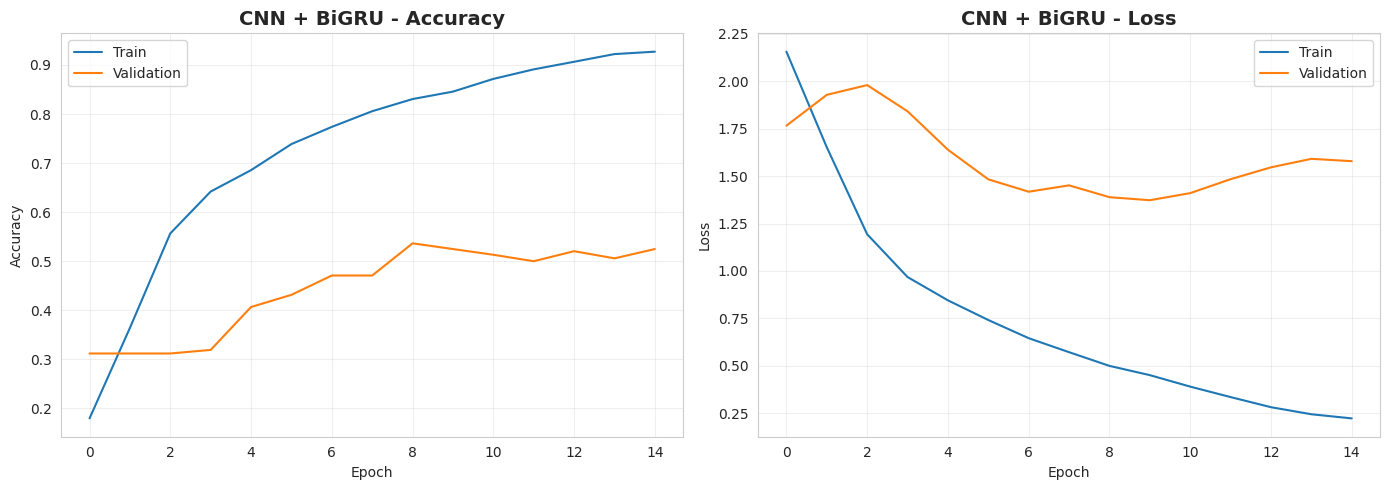

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(best_history.history['accuracy'], label='Train')
ax1.plot(best_history.history['val_accuracy'], label='Validation')
ax1.set_title('CNN + BiGRU - Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(best_history.history['loss'], label='Train')
ax2.plot(best_history.history['val_loss'], label='Validation')
ax2.set_title('CNN + BiGRU - Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Confusion Matrix & Classification Report

In [1]:
print(f"\n{'='*80}")
print("CONFUSION MATRIX FOR TEST SET")
print(f"{'='*80}\n")

y_test_prob = best_model_ref.predict(X_test_pad, batch_size=VAL_BATCH_SIZE, verbose=0)
predictions = np.argmax(y_test_prob, axis=1)
true_labels = y_test

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[id2label[i] for i in range(num_classes)],
    yticklabels=[id2label[i] for i in range(num_classes)],
)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Test Set (CNN + BiGRU)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print("CLASSIFICATION REPORT - TEST SET")
print(f"{'='*80}\n")
print(classification_report(
    true_labels,
    predictions,
    target_names=[id2label[i] for i in range(num_classes)],
))

test_accuracy = accuracy_score(true_labels, predictions)
test_f1_macro = f1_score(true_labels, predictions, average='macro')
test_f1_weighted = f1_score(true_labels, predictions, average='weighted')

print(f"Test Accuracy:    {test_accuracy:.4f}")
print(f"Test F1 Macro:    {test_f1_macro:.4f}")
print(f"Test F1 Weighted: {test_f1_weighted:.4f}")

print(f"\n{'='*80}")
print("Confusion matrix and classification report generated.")
print(f"{'='*80}\n")


CONFUSION MATRIX FOR TEST SET



NameError: name 'best_model_ref' is not defined

## 11. Save Model to Google Drive

In [ ]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
versioned_path = os.path.join(MODEL_SAVE_PATH, f'cnn_bigru_{timestamp}')
os.makedirs(versioned_path, exist_ok=True)

model_file = os.path.join(versioned_path, 'cnn_bigru_model.keras')
best_model_ref.save(model_file)
print(f"Model saved to: {model_file}")

label_mappings = {
    'label2id': label2id,
    'id2label': id2label,
    'classes': list(le.classes_),
}
with open(os.path.join(versioned_path, 'label_mappings.json'), 'w', encoding='utf-8') as f:
    json.dump(label_mappings, f, ensure_ascii=False, indent=2)
print("Label mappings saved")

tokenizer_config = text_tokenizer.get_config()
with open(os.path.join(versioned_path, 'tokenizer_config.json'), 'w', encoding='utf-8') as f:
    json.dump(tokenizer_config, f, ensure_ascii=False, indent=2)
print("Tokenizer config saved")

metadata = {
    'model_type': 'CNN-BiGRU',
    'timestamp': timestamp,
    'vocab_size': int(vocab_size),
    'max_seq_len': MAX_SEQ_LEN,
    'embed_dim': EMBED_DIM,
    'cnn_filters': CNN_FILTERS,
    'cnn_kernel_sizes': CNN_KERNEL_SIZES,
    'gru_units': GRU_UNITS,
    'num_classes': num_classes,
    'k_folds': K_FOLDS,
    'best_fold': int(best_fold_idx),
    'test_accuracy': float(test_accuracy),
    'test_f1_macro': float(test_f1_macro),
    'test_f1_weighted': float(test_f1_weighted),
    'training_config': {
        'learning_rate': LEARNING_RATE,
        'batch_size': TRAIN_BATCH_SIZE,
        'epochs': NUM_EPOCHS,
        'early_stopping_patience': EARLY_STOPPING_PATIENCE,
    },
}
with open(os.path.join(versioned_path, 'model_metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print("Model metadata saved")

print(f"\n{'='*80}")
print(f"All artifacts saved to: {versioned_path}")
print(f"{'='*80}")

wandb.finish()
print("\nW&B run finished")

import time
time.sleep(5)
try:
    from google.colab import runtime
    runtime.unassign()
except Exception:
    pass